In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.7 MB/s eta 0:00:00


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import optuna
import shap
import time

In [ ]:
# Загрузка и подготовка данных
df = pd.read_csv("hypertension_dataset.csv")
df['Medication'] = df['Medication'].fillna('None')
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

# Масштабирование числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


# Optuna – это инструмент, предназначенный для автоматического подбора наилучших параметров для моделей машинного обучения.

Optuna выделяется использованием умных
алгоритмов, которые анализируют предыдущие попытки и сосредотачиваются
на наиболее перспективных областях параметров. По эффективности Optuna
превосходит Grid Search и Random Search. Фреймворк гибок в настройке
параметров, прост в использовании, предоставляет инструменты
визуализации,
поддерживает
параллелизацию
бесперспективные попытки обучения.

In [ ]:
def objective(trial):
    """Функция цели для Optuna, которая минимизирует ошибку (максимизирует точность)."""

    # Гиперпараметры для оптимизации
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }

    model = RandomForestClassifier(**params)
    # Используем кросс-валидацию для оценки качества
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()
    return score

# Запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Получение лучших результатов
best_params = study.best_params
print(f"Оптимальные гиперпараметры (Optuna): {best_params}")

# Обучение финальной модели
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# Оценка качества на тестовой выборке
y_pred = best_rf.predict(X_test)
print("\nОтчет по классификации (Оптимизированный RF на исходных данных):")
print(classification_report(y_test, y_pred))


[I 2025-11-11 16:20:46,986] A new study created in memory with name: no-name-fe57e79d-3161-4381-b9c4-88f4d7acbc04


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-11 16:20:51,224] Trial 0 finished with value: 0.9222320338674909 and parameters: {'n_estimators': 217, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.9222320338674909.
[I 2025-11-11 16:20:52,613] Trial 1 finished with value: 0.9582448120925642 and parameters: {'n_estimators': 123, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9582448120925642.
[I 2025-11-11 16:20:54,066] Trial 2 finished with value: 0.9647118406357945 and parameters: {'n_estimators': 106, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 2 with value: 0.9647118406357945.
[I 2025-11-11 16:20:54,912] Trial 3 finished with value: 0.9402332285795912 and parameters: {'n_estimators': 98, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 2 with value: 0.9647118406357945.
[I 2025

Оптимальные гиперпараметры (Optuna): {'n_estimators': 278, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 3, 'criterion': 'entropy'}

 Определение оптимального количества компонент PCA 
Оптимальное N компонент PCA для максимальной точности: 12.0
Максимальная точность при этом N: 0.8490


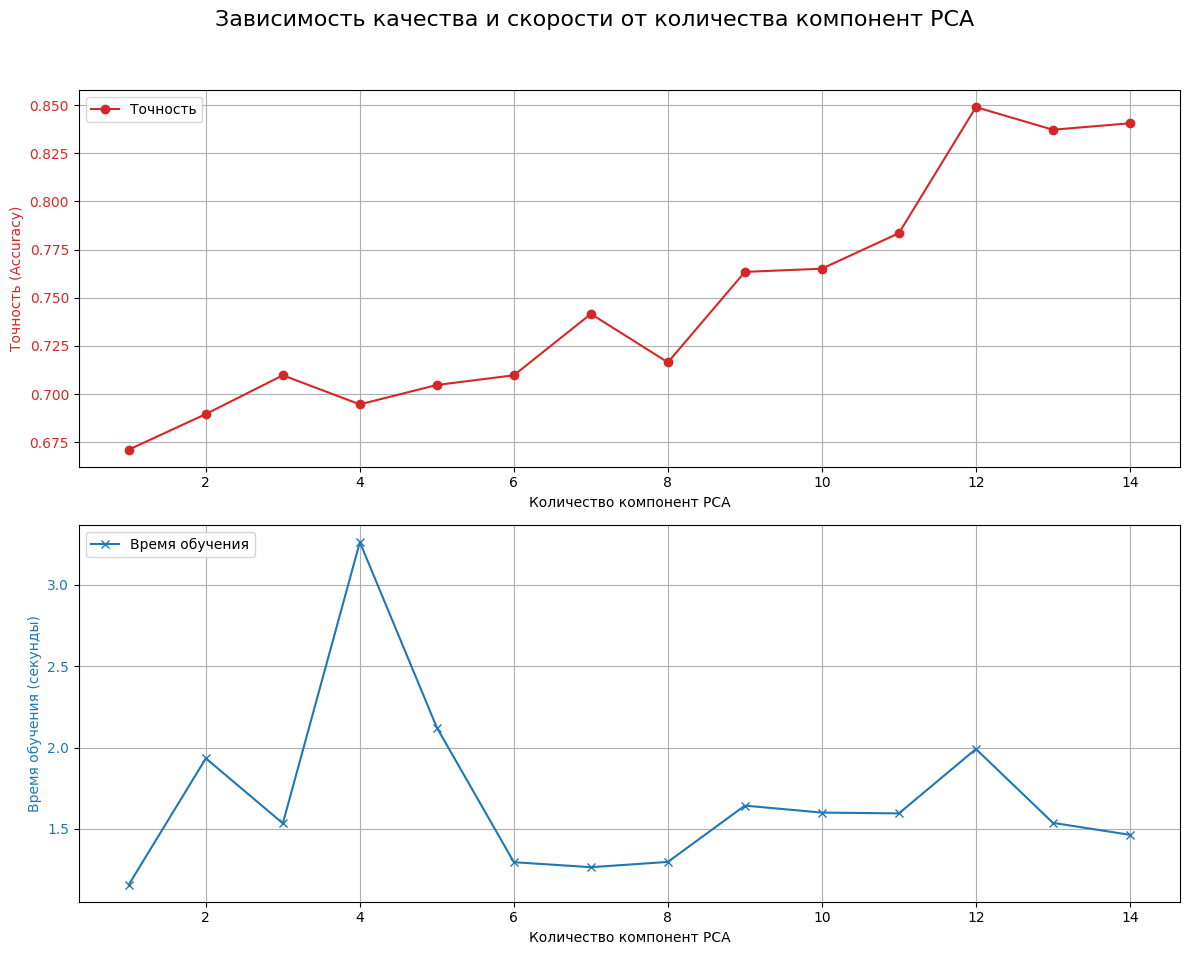

In [ ]:
# Получаем оптимальные гиперпараметры из Optuna
best_params = study.best_params
print(f"Оптимальные гиперпараметры (Optuna): {best_params}")

n_features = X_scaled.shape[1]  # Количество признаков
pca_results = []  # Список для хранения результатов

for n in range(1, n_features + 1):
    start_time = time.time()  # Запоминаем время начала

    # 1. Применяем PCA
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # 2. Обучаем Random Forest
    rf_pca = RandomForestClassifier(**best_params, random_state=42)
    rf_pca.fit(X_train_pca, y_train)

    train_time = time.time() - start_time  # Время обучения

    # 3. Оценка качества
    y_pred_pca = rf_pca.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred_pca)

    pca_results.append({
        'n_components': n,
        'accuracy': accuracy,
        'time': train_time
    })

# Преобразуем результаты в DataFrame
pca_df = pd.DataFrame(pca_results)
optimal_pca_n = pca_df.loc[pca_df['accuracy'].idxmax()]

# Выводим оптимальные результаты
print("\n Определение оптимального количества компонент PCA ")
print(f"Оптимальное N компонент PCA для максимальной точности: {optimal_pca_n['n_components']}")
print(f"Максимальная точность при этом N: {optimal_pca_n['accuracy']:.4f}")

# Построение графиков

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Первый график: Качество (Точность)
ax1 = axes[0]
color = 'tab:red'
ax1.set_xlabel('Количество компонент PCA')
ax1.set_ylabel('Точность (Accuracy)', color=color)
ax1.plot(pca_df['n_components'], pca_df['accuracy'], color=color, marker='o', label='Точность')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)
ax1.legend(loc='upper left')

# Второй график: Скорость (Время обучения)
ax2 = axes[1]
color = 'tab:blue'
ax2.set_xlabel('Количество компонент PCA')
ax2.set_ylabel('Время обучения (секунды)', color=color)
ax2.plot(pca_df['n_components'], pca_df['time'], color=color, marker='x', label='Время обучения')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(True)
ax2.legend(loc='upper left')

# Устанавливаем общий заголовок для всей фигуры
fig.suptitle('Зависимость качества и скорости от количества компонент PCA', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('pca_quality_speed_analysis_subplots.png')
plt.show()

## Анализ:
Качество (accuracy) растёт в целом с увеличением числа компонент: от ~ 0.67 (1 комп.) до пика ~ 0.85 при 12 компонентах, затем слегка стабилизируется (≈ 0.83–0.84 при 13–14).
Время обучения непостоянно: есть выбросы при 3-4 и 12 компонентах, в остальном время уменьшается к ~ 1.4–1.6 с при больших числах компонент.

## Вывод:
Лучшее соотношение качество/скорость — 12 компонент: максимальная точность и приемлемое (низкое) время обучения.

In [ ]:
# Оценка качества модели при 12 компонентах
pca_12 = PCA(n_components=12)
X_train_pca_12 = pca_12.fit_transform(X_train)
X_test_pca_12 = pca_12.transform(X_test)

rf_pca_12 = RandomForestClassifier(**best_params, random_state=42)
rf_pca_12.fit(X_train_pca_12, y_train)

y_pred_pca_12 = rf_pca_12.predict(X_test_pca_12)

# Вывод отчета о качестве модели
print("\n Оценка качества модели при 12 компонентах")
print(classification_report(y_test, y_pred_pca_12, target_names=['0', '1']))


 Оценка качества модели при 12 компонентах
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       286
           1       0.83      0.89      0.86       310

    accuracy                           0.85       596
   macro avg       0.85      0.85      0.85       596
weighted avg       0.85      0.85      0.85       596



## Анализ:
Оптимизированная модель на исходных данных:
Precision: 0.95 для класса 0, 0.97 для класса 1.
Recall: 0.97 для класса 0, 0.95 для класса 1.
F1-score: 0.96 для обоих классов.
Accuracy: 96%.

Оптимизированная модель показывает отличные результаты, с высокой точностью и сбалансированными показателями для обоих классов.

Модель на 12 компонентах PCA:
Precision: 0.87 для класса 0, 0.83 для класса 1.
Recall: 0.81 для класса 0, 0.89 для класса 1.
F1-score: 0.84 для класса 0, 0.86 для класса 1.
Accuracy: 85%.

Снижение производительности по сравнению с исходными данными, что указывает на потерю информации при уменьшении размерности.

## Вывод:

Оптимизированная модель RF на исходных данных демонстрирует высокую эффективность, в то время как использование PCA приводит к снижению точности и других метрик, подчеркивая важность сохранения полной информации для достижения лучших результатов в классификации.